<a href="https://colab.research.google.com/github/Nivethika-hub/nivethika-codebooster-2026/blob/main/Day-5/day_5project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
API_KEY ='b81f00d0660cef10842f8263367344a0'
BASE_URL='https://api.openweathermap.org/data/2.5/weather'
CITIES =['Mumbai','Delhi','Bangalore','Chennai','Hyderbad','Kolkata', 'Pune','Jaipur']
print(f'API configured for {len(CITIES)} cities')
print(f'Cities:{CITIES}')

API configured for 8 cities
Cities:['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderbad', 'Kolkata', 'Pune', 'Jaipur']


In [3]:
import requests

def fetch_weather(city, api_key):
  """
  Fetch current weather data for a given city.
  Returns a dictionary with weather metrics, or None on failure.
  """

  params = {
      'q': city,
      'appid': api_key,
      'units': 'metric'
  }

  try:
    response = requests.get(BASE_URL, params=params, timeout=10)
    response.raise_for_status() # Raises HTTPError for bad responses (4xx or 5xx)

    data = response.json()

    return {
        'city': city,
        'temperature': round(data['main']['temp'], 1),
        'feels_like': round(data['main']['feels_like'], 1),
        'humidity': data['main']['humidity'],
        'pressure': data['main']['pressure'],
        'wind_speed': data['wind']['speed'],
        'condition': data['weather'][0]['description'],
        'visibiilty': data['visibility']
    }

  except requests.exceptions.HTTPError as http_err:
    print(f'HTTP error occurred for {city}: {http_err}')
    return None
  except requests.exceptions.ConnectionError as conn_err:
    print(f'Connection error occurred for {city}: {conn_err}')
    return None
  except requests.exceptions.Timeout as timeout_err:
    print(f'Timeout error occurred for {city}: {timeout_err}')
    return None
  except requests.exceptions.RequestException as req_err:
    print(f'An error occurred during the request for {city}: {req_err}')
    return None
  except Exception as e:
    print(f'An unexpected error occurred for {city}: {e}')
    return None

In [4]:
import requests
import pandas as pd

weather_data = []

for city in CITIES:
  weather = fetch_weather(city, API_KEY)
  if weather:
    weather_data.append(weather)

df_weather = pd.DataFrame(weather_data)
display(df_weather)

HTTP error occurred for Hyderbad: 404 Client Error: Not Found for url: https://api.openweathermap.org/data/2.5/weather?q=Hyderbad&appid=b81f00d0660cef10842f8263367344a0&units=metric


,city,temperature,feels_like,humidity,pressure,wind_speed,condition,visibiilty
0,Mumbai,35.0,42.0,55,1008,5.14,smoke,5000
1,Delhi,35.0,36.2,36,1005,3.09,clear sky,7000
2,Bangalore,31.6,34.9,55,1009,5.81,scattered clouds,8000
3,Chennai,34.2,41.2,59,1005,5.14,scattered clouds,6000
4,Kolkata,34.0,41.0,62,1003,2.57,haze,4000
5,Pune,35.8,35.1,27,1007,6.05,clear sky,10000
6,Jaipur,34.6,33.9,29,1005,4.12,haze,5000


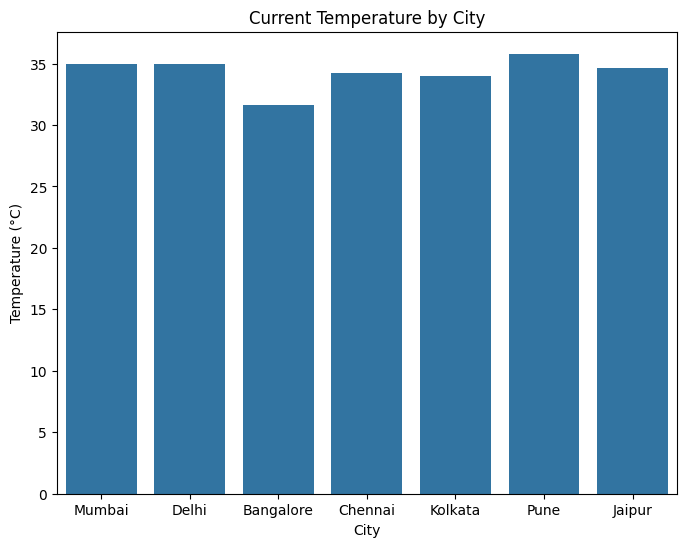

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))
sns.barplot(x='city', y='temperature', data=df_weather)
plt.title('Current Temperature by City')
plt.xlabel('City')
plt.ylabel('Temperature (°C)')
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score




X = df_weather.drop(columns=['city', 'condition', 'temperature'])
y = df_weather['temperature']

print(f"Features (X): {list(X.columns)}")
print(f"Target (y): temperature")


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Features (X): ['feels_like', 'humidity', 'pressure', 'wind_speed', 'visibiilty']
Target (y): temperature

Training set size: 5 samples
Testing set size: 2 samples


#### Train the Model

Now, we'll train a `LinearRegression` model using our training data.

In [7]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


#### Make Predictions and Evaluate

Let's see how our model performs on the test data.

In [8]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display actual vs. predicted values for a few samples
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(results_df)

Mean Absolute Error (MAE): 0.63
R-squared (R2): 0.00


,Actual,Predicted
0,35.0,33.958974
1,35.0,35.220045


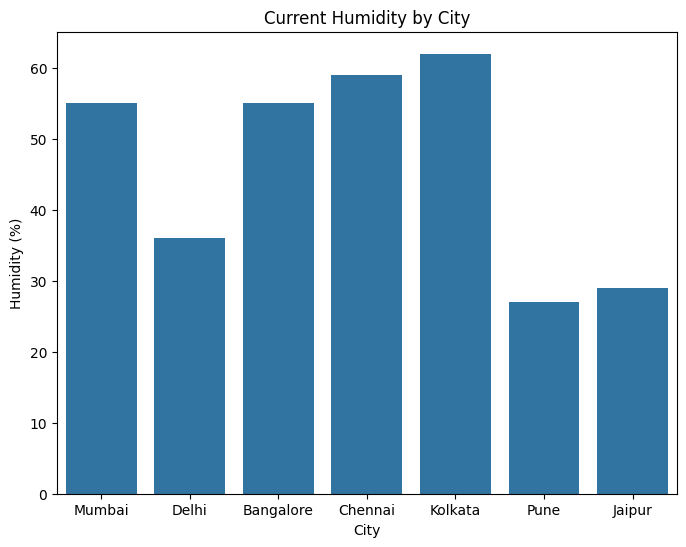

In [9]:
plt.figure(figsize=(8, 6))
sns.barplot(x='city', y='humidity', data=df_weather)
plt.title('Current Humidity by City')
plt.xlabel('City')
plt.ylabel('Humidity (%)')
plt.show()

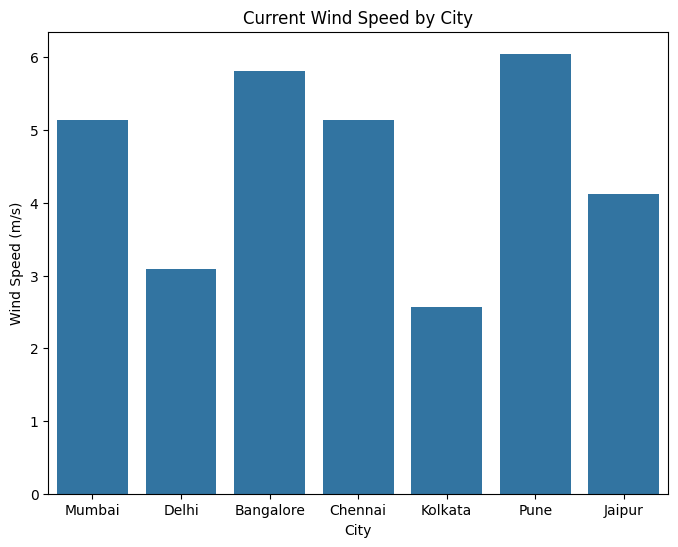

In [10]:
plt.figure(figsize=(8, 6))
sns.barplot(x='city', y='wind_speed', data=df_weather)
plt.title('Current Wind Speed by City')
plt.xlabel('City')
plt.ylabel('Wind Speed (m/s)')
plt.show()

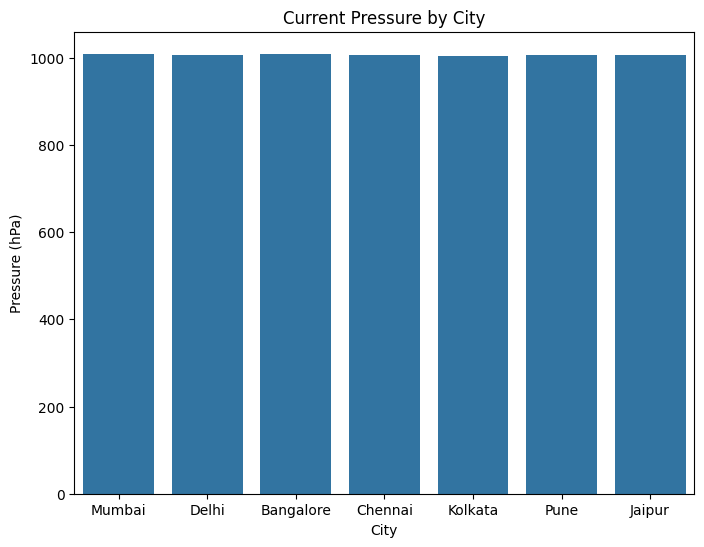

In [11]:
plt.figure(figsize=(8, 6))
sns.barplot(x='city', y='pressure', data=df_weather)
plt.title('Current Pressure by City')
plt.xlabel('City')
plt.ylabel('Pressure (hPa)')
plt.show()

Additionally, let's look at a pair plot to understand the relationships between different numerical features.

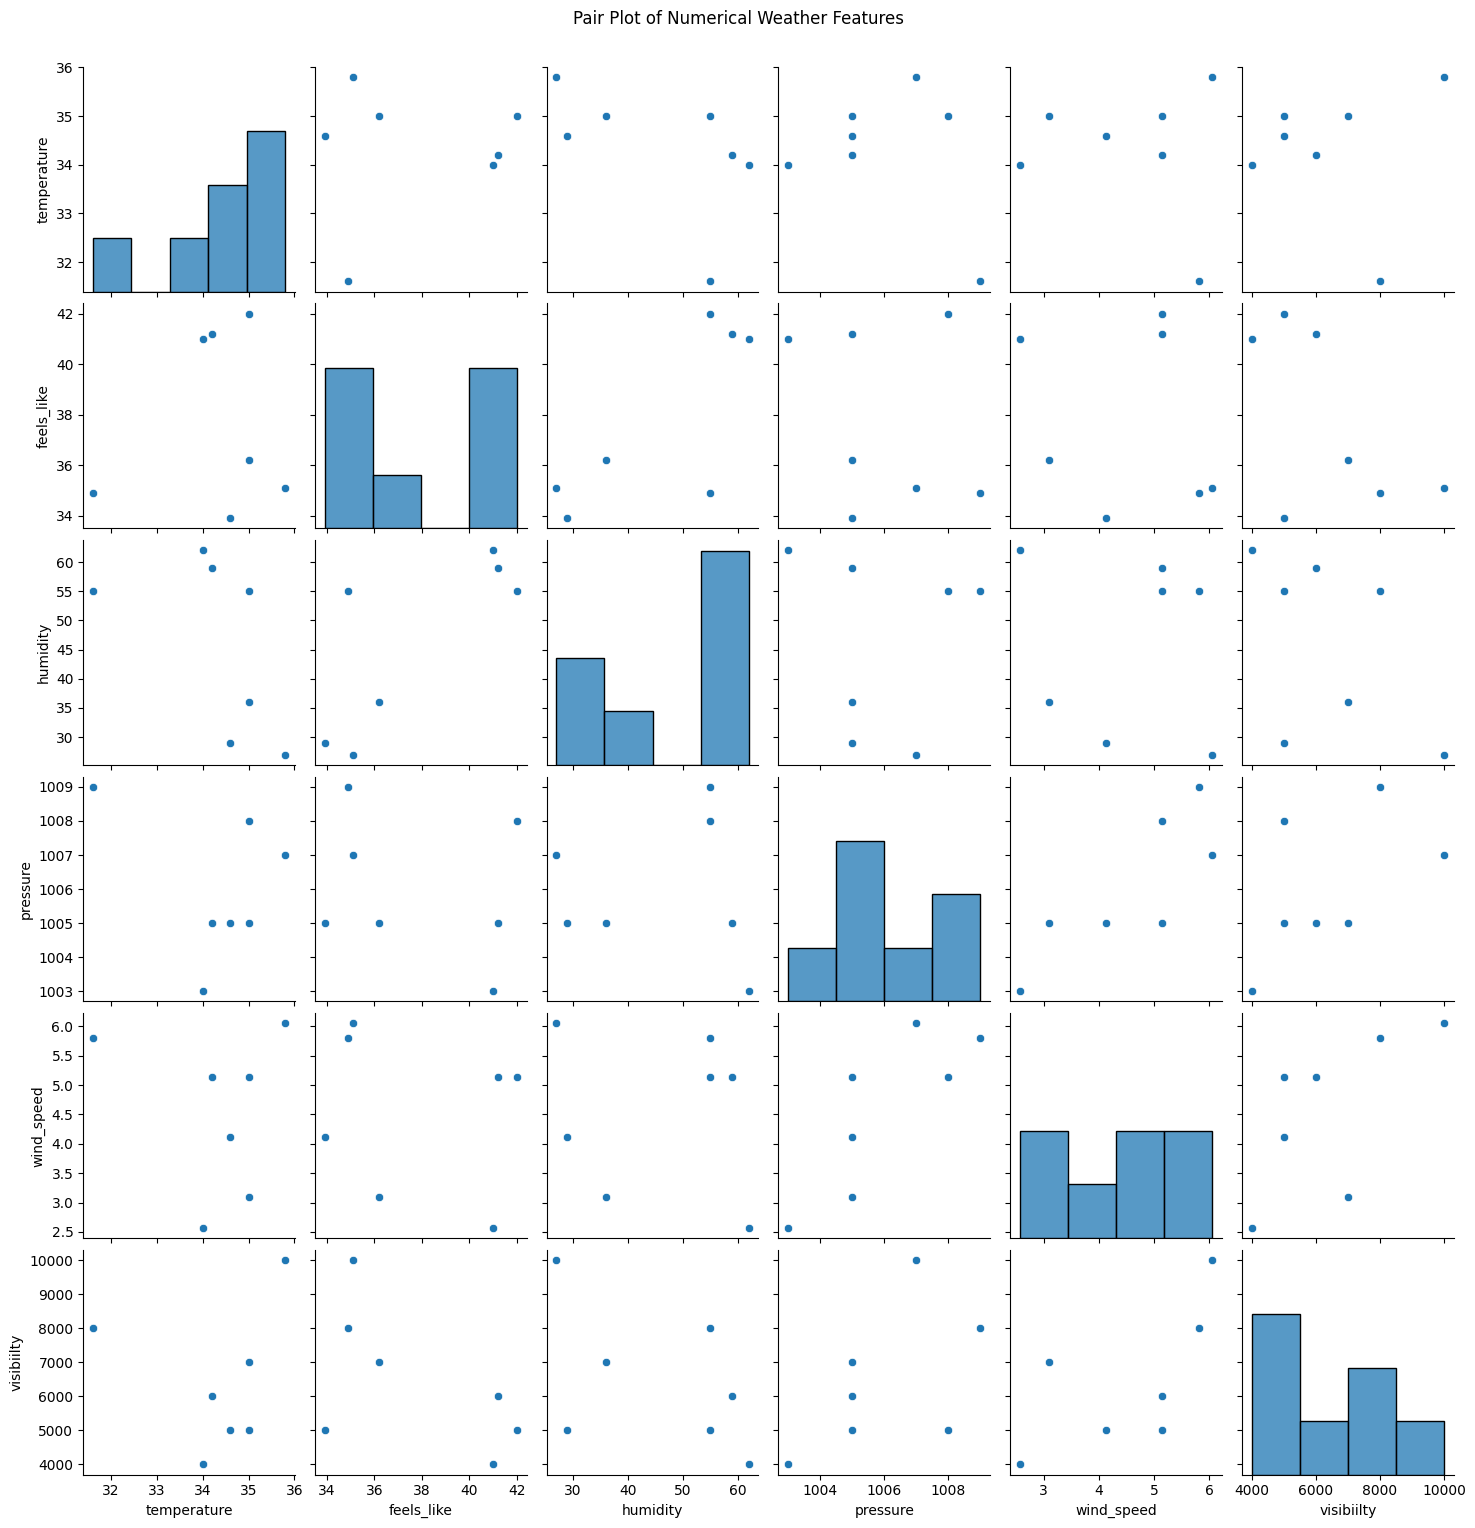

In [12]:
numerical_features = ['temperature', 'feels_like', 'humidity', 'pressure', 'wind_speed', 'visibiilty']
sns.pairplot(df_weather[numerical_features])
plt.suptitle('Pair Plot of Numerical Weather Features', y=1.02) # Adjust suptitle position
plt.show()